Cell 1 — Load data

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv('../data/AmesHousing.csv')
print(df.shape)
df.head()

(2930, 82)


,Order,PID,MS SubClass,MS Zoning,Lot Frontage,Lot Area,Street,Alley,Lot Shape,Land Contour,...,Pool Area,Pool QC,Fence,Misc Feature,Misc Val,Mo Sold,Yr Sold,Sale Type,Sale Condition,SalePrice
0,1,526301100,20,RL,141.0,31770,Pave,NaN,IR1,Lvl,...,0,NaN,NaN,NaN,0,5,2010,WD,Normal,215000
1,2,526350040,20,RH,80.0,11622,Pave,NaN,Reg,Lvl,...,0,NaN,MnPrv,NaN,0,6,2010,WD,Normal,105000
2,3,526351010,20,RL,81.0,14267,Pave,NaN,IR1,Lvl,...,0,NaN,NaN,Gar2,12500,6,2010,WD,Normal,172000
3,4,526353030,20,RL,93.0,11160,Pave,NaN,Reg,Lvl,...,0,NaN,NaN,NaN,0,4,2010,WD,Normal,244000
4,5,527105010,60,RL,74.0,13830,Pave,NaN,IR1,Lvl,...,0,NaN,MnPrv,NaN,0,3,2010,WD,Normal,189900


Cell 2 — Info dasar

In [2]:
print(df.dtypes.value_counts())
print("\nMissing values:")
print(df.isnull().sum().sort_values(ascending=False).head(20))

object     43
int64      28
float64    11
Name: count, dtype: int64

Missing values:
Pool QC           2917
Misc Feature      2824
Alley             2732
Fence             2358
Mas Vnr Type      1775
Fireplace Qu      1422
Lot Frontage       490
Garage Qual        159
Garage Yr Blt      159
Garage Cond        159
Garage Finish      159
Garage Type        157
Bsmt Exposure       83
BsmtFin Type 2      81
Bsmt Qual           80
Bsmt Cond           80
BsmtFin Type 1      80
Mas Vnr Area        23
Bsmt Full Bath       2
Bsmt Half Bath       2
dtype: int64


Cell 3 — Target variable

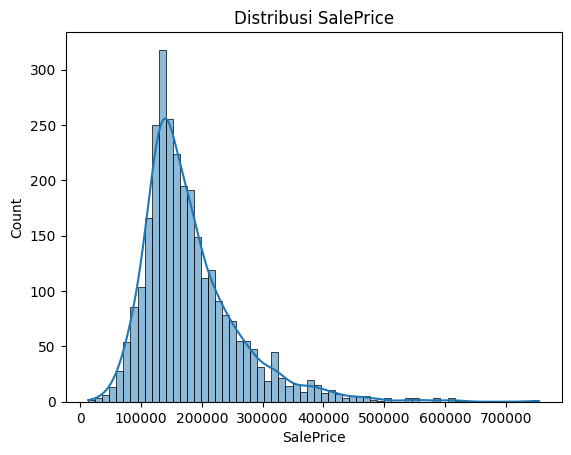

count      2930.000000
mean     180796.060068
std       79886.692357
min       12789.000000
25%      129500.000000
50%      160000.000000
75%      213500.000000
max      755000.000000
Name: SalePrice, dtype: float64


In [3]:
sns.histplot(df['SalePrice'], kde=True)
plt.title('Distribusi SalePrice')
plt.show()

print(df['SalePrice'].describe())

Cell 4 — Korelasi numerik dengan SalePrice

In [4]:
numeric_cols = df.select_dtypes(include=[np.number]).columns
corr = df[numeric_cols].corr()['SalePrice'].sort_values(ascending=False)
print(corr.head(15))

SalePrice         1.000000
Overall Qual      0.799262
Gr Liv Area       0.706780
Garage Cars       0.647877
Garage Area       0.640401
Total Bsmt SF     0.632280
1st Flr SF        0.621676
Year Built        0.558426
Full Bath         0.545604
Year Remod/Add    0.532974
Garage Yr Blt     0.526965
Mas Vnr Area      0.508285
TotRms AbvGrd     0.495474
Fireplaces        0.474558
BsmtFin SF 1      0.432914
Name: SalePrice, dtype: float64


Cell 5 — Top features scatter plot

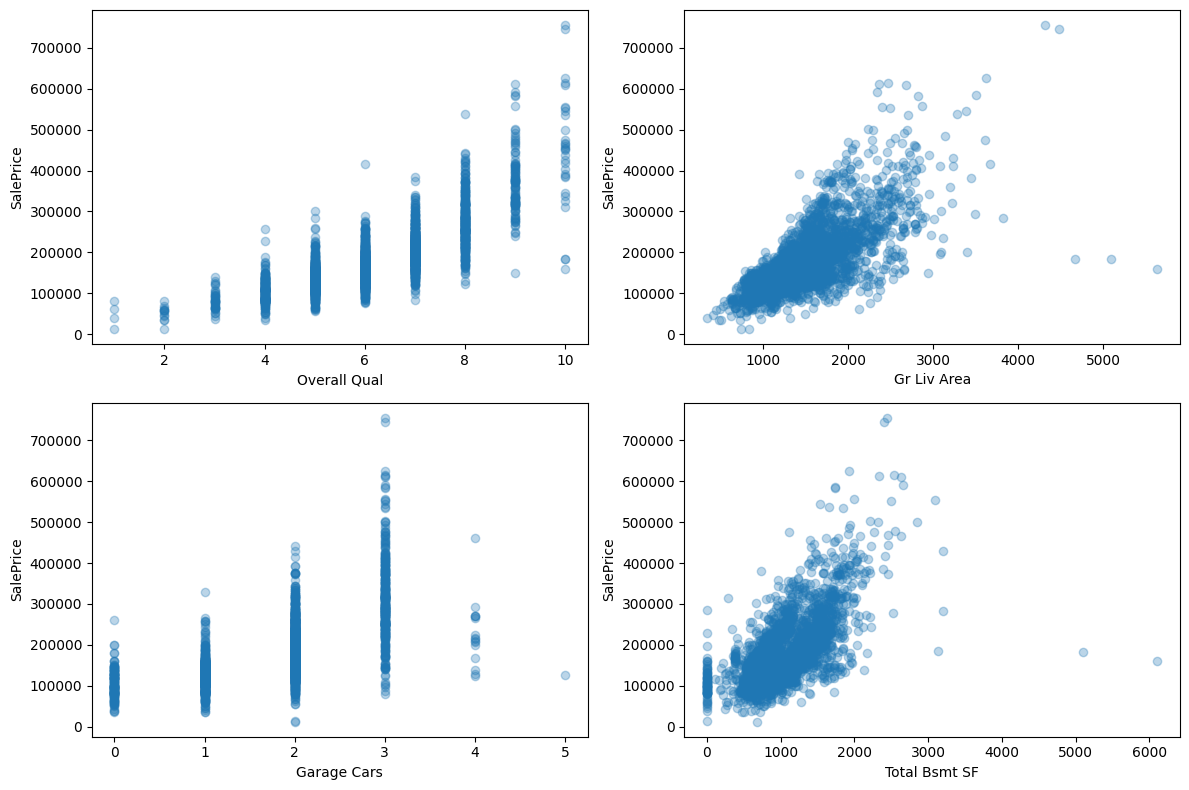

In [5]:
top_features = ['Overall Qual', 'Gr Liv Area', 'Garage Cars', 'Total Bsmt SF']

fig, axes = plt.subplots(2, 2, figsize=(12, 8))
for i, feat in enumerate(top_features):
    ax = axes[i//2, i%2]
    ax.scatter(df[feat], df['SalePrice'], alpha=0.3)
    ax.set_xlabel(feat)
    ax.set_ylabel('SalePrice')
plt.tight_layout()
plt.savefig('../outputs/eda-charts.png', dpi=150)
plt.show()